In [45]:
# from dotenv import load_dotenv
# load_dotenv()

In [46]:
import json
import textwrap
import pandas as pd
from ipywidgets import widgets
from IPython.display import display
from ipywidgets import HBox
import matplotlib.pyplot as plt
from tabulate import tabulate

In [47]:
# Load the wandb table data
def load_wandb_data(filepath):
    with open(filepath, 'r') as f:
        data = json.load(f)
    return pd.DataFrame(data['data'], columns=data['columns'])

In [48]:
def fixedwidth(text):
    """Wrap text to fixed width"""
    return "\n".join(textwrap.wrap(str(text), width=160, replace_whitespace=False))

def format_row(row):
    """Format a single row for display as a table"""
    data = [
        ["Step", row['Step']],
        ["Reward", f"{row['Reward']:.2f}"],
        ["Input", row['Input']],
        ["Prompt", fixedwidth(row['Prompt'])], 
        ["Completion", fixedwidth(row['Completion'])],
    ]
    return tabulate(data, tablefmt='grid')

def present_row(row):
    """Display a formatted row as table"""
    print(format_row(row))

In [49]:
def create_browse_app(df):
    """Create an interactive widget to browse through the data"""
    def browse_data(i=0):
        row = df.iloc[i]
        present_row(row)

    index = widgets.IntText(value=0, description='Index:')
    left_button = widgets.Button(description='Previous')
    right_button = widgets.Button(description='Next')

    def on_left_button_clicked(b):
        if index.value > 0:
            index.value -= 1

    def on_right_button_clicked(b):
        if index.value < len(df) - 1:
            index.value += 1

    left_button.on_click(on_left_button_clicked)
    right_button.on_click(on_right_button_clicked)

    ui = HBox([left_button, index, right_button])
    out = widgets.interactive_output(browse_data, {'i': index})

    display(ui, out)

In [50]:
def preprocess_df(df):
    df['Step'] = df['Step'].astype(int)
    df['Reward'] = df['Reward'].astype(float)
    df['Input'] = df['Input'].astype(str)
    df['Prompt'] = df['Prompt'].astype(str)
    df['Completion'] = df['Completion'].astype(str)
    df['Prompt'] = df['Prompt'].map(lambda x: x.rsplit('**user**:', 1)[-1])
    df.sort_values(by="Step", ascending=False, inplace=True)
    return df

In [51]:
# Load and display your data
from pathlib import Path

# read all json files in the directory using pathlib
run_name = 'run-20250309_144639-pu78jort'
directory = f"../wandb/{run_name}/files/media/table"
files = list(Path(directory).glob("interactions_*.json"))

# load all json files
df = pd.concat([load_wandb_data(f) for f in files])
df = preprocess_df(df)
print(len(df))

89856


In [52]:
df.loc[df['Completion'].str.contains("timed out")]

,Step,Input,Prompt,Completion,Reward
31,660,answer: Tehran\n\nanswers: ['Tehran']\n\nsuppo...,In which city is the university associated wi...,**assistant**: According to the information pr...,0.50
14,618,answer: eleven years old\n\nanswers: ['eleven ...,How old was the performer of Can't Be Tamed w...,**assistant**: <think>\nLet's use the informat...,0.47
12,606,answer: 46%\n\nanswers: ['46%']\n\nsupporting_...,What percent of people in the country where V...,**assistant**: The population living in Vitali...,0.25
4,528,answer: Eastern United States\n\nanswers: ['Ea...,Where is the river that is crossed by the Fre...,**assistant**: <think>\nI need to find the riv...,0.57
9,468,answer: 1937\n\nanswers: ['1937']\n\nsupportin...,When was the Golden Gate Bridge built in the ...,"**assistant**: <think>\nFirst, I need to find ...",0.22
12,428,answer: Goodluck Jonathan\n\nanswers: ['Goodlu...,Who is the President of the country with the ...,"**assistant**: <tool>\n{""name"": ""retrieve"", ""a...",0.18
23,380,answer: James McCartney\n\nanswers: ['James Mc...,Whose father wrote Come and Get It?,"**assistant**: <think>\nTo find the answer, I ...",0.46
20,380,answer: James McCartney\n\nanswers: ['James Mc...,Whose father wrote Come and Get It?,"**assistant**: Think of a screenplay titled ""C...",0.36
32,372,answer: Northwestern's School of Communication...,Where did a cast member from Mickey One go to...,"**assistant**: <think>\nTo answer this, I shou...",0.69
1,336,answer: February 1943\n\nanswers: ['February 1...,"When did the country, whose cars would eventu...","**assistant**: <think>\nFirst, I need to find ...",0.49


In [53]:
# Create the interactive browser
create_browse_app(df)

Output()

In [54]:
retrieval_attempt_mask = df['Completion'].str.contains("timed out")
df.loc[retrieval_attempt_mask]

,Step,Input,Prompt,Completion,Reward
31,660,answer: Tehran\n\nanswers: ['Tehran']\n\nsuppo...,In which city is the university associated wi...,**assistant**: According to the information pr...,0.50
14,618,answer: eleven years old\n\nanswers: ['eleven ...,How old was the performer of Can't Be Tamed w...,**assistant**: <think>\nLet's use the informat...,0.47
12,606,answer: 46%\n\nanswers: ['46%']\n\nsupporting_...,What percent of people in the country where V...,**assistant**: The population living in Vitali...,0.25
4,528,answer: Eastern United States\n\nanswers: ['Ea...,Where is the river that is crossed by the Fre...,**assistant**: <think>\nI need to find the riv...,0.57
9,468,answer: 1937\n\nanswers: ['1937']\n\nsupportin...,When was the Golden Gate Bridge built in the ...,"**assistant**: <think>\nFirst, I need to find ...",0.22
12,428,answer: Goodluck Jonathan\n\nanswers: ['Goodlu...,Who is the President of the country with the ...,"**assistant**: <tool>\n{""name"": ""retrieve"", ""a...",0.18
23,380,answer: James McCartney\n\nanswers: ['James Mc...,Whose father wrote Come and Get It?,"**assistant**: <think>\nTo find the answer, I ...",0.46
20,380,answer: James McCartney\n\nanswers: ['James Mc...,Whose father wrote Come and Get It?,"**assistant**: Think of a screenplay titled ""C...",0.36
32,372,answer: Northwestern's School of Communication...,Where did a cast member from Mickey One go to...,"**assistant**: <think>\nTo answer this, I shou...",0.69
1,336,answer: February 1943\n\nanswers: ['February 1...,"When did the country, whose cars would eventu...","**assistant**: <think>\nFirst, I need to find ...",0.49


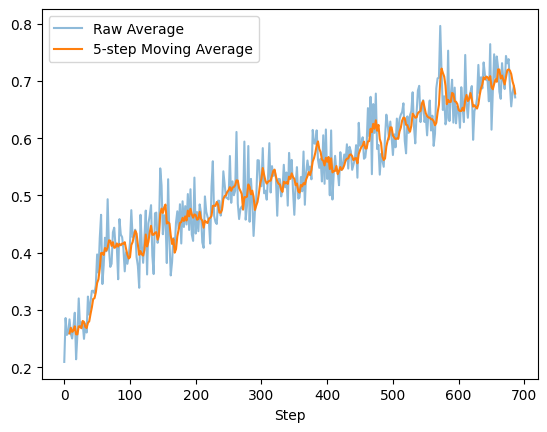

In [55]:
# plot average reward by step
# Plot raw average and moving average
means = df.groupby('Step')['Reward'].mean()
means.plot(alpha=0.5, label='Raw Average')
means.rolling(window=5).mean().plot(label='5-step Moving Average')
plt.legend()

In [56]:
from ast import literal_eval

def extract_titles(completion):
    # Extract titles from the completion
    for line in completion.splitlines():
        if line.startswith('#'):
            yield line.split('#')[1].strip()

# Apply the function to the 'Completion' column
df['Retrieved Titles'] = df['Completion'].apply(lambda x: list(extract_titles(x)))

df['Supporting Titles'] = df['Input'].map(lambda x: x.split('supporting_titles:', 1)[-1]).map(literal_eval)


<Axes: >

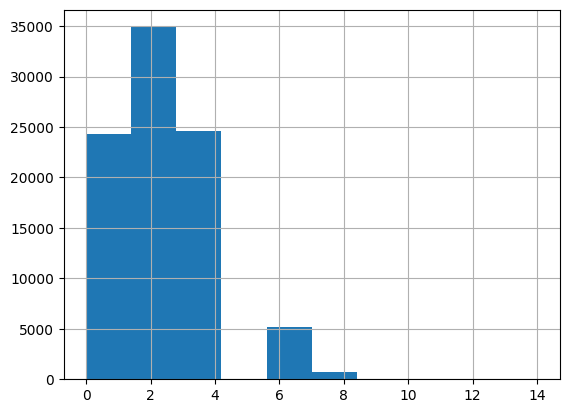

In [57]:
df['Retrieved Titles'].map(len).hist()

In [58]:
df['Successfully Retrieved Titles'] = df.apply(lambda row: set(row['Retrieved Titles']).intersection(row['Supporting Titles']), axis=1)
df['retrieval.recall'] = df['Successfully Retrieved Titles'].map(len) / df['Supporting Titles'].map(len)
df['retrieval.precision'] = df['Successfully Retrieved Titles'].map(len) / df['Retrieved Titles'].map(len)

In [59]:
retrieval_attempt_mask = df['Retrieved Titles'].map(len) > 0
len(df[retrieval_attempt_mask]) / len(df)

0.7294671474358975

In [60]:
df.loc[retrieval_attempt_mask, 'retrieval.recall'].describe()

count    65547.000000
mean         0.617031
std          0.290469
min          0.000000
25%          0.500000
50%          0.500000
75%          1.000000
max          1.000000
Name: retrieval.recall, dtype: float64

In [61]:
df.loc[retrieval_attempt_mask, 'retrieval.precision'].describe()

count    65547.000000
mean         0.431259
std          0.218003
min          0.000000
25%          0.250000
50%          0.500000
75%          0.500000
max          1.000000
Name: retrieval.precision, dtype: float64

In [62]:
error_mask = df['Completion'].str.contains("Error")
len(df.loc[error_mask]) / len(df)


0.03985265313390313

<Axes: >

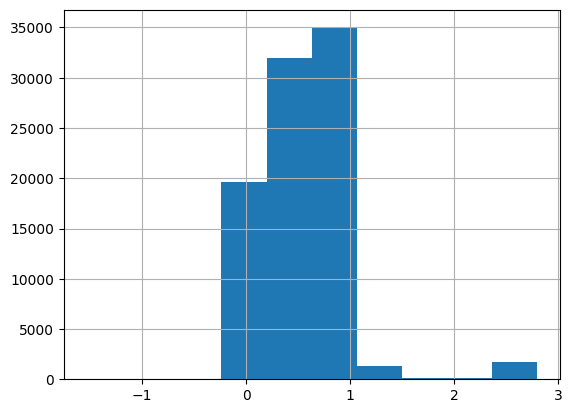

In [63]:
df['Reward'].hist()

In [64]:
# plot reward distribution characteristics per prompt
prompt_reward_stats = df.groupby('Prompt')['Reward'].describe()

<Axes: xlabel='std', ylabel='mean'>

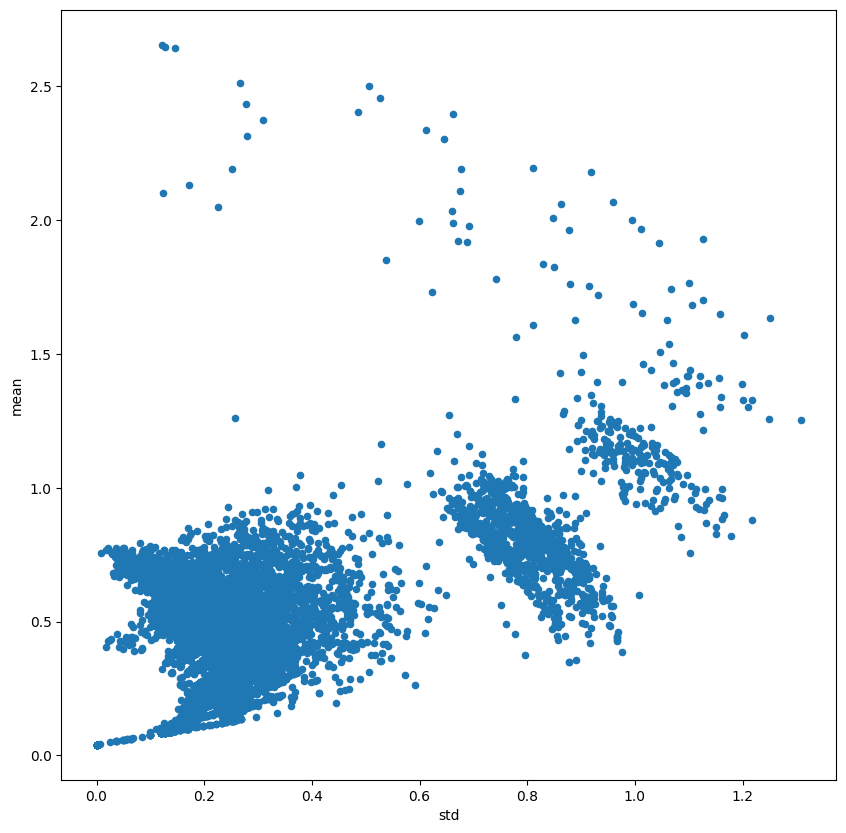

In [65]:
prompt_reward_stats.plot.scatter(x='std', y='mean', figsize=(10, 10))